<a href="https://colab.research.google.com/github/vyshnavip2206/PRODIGY_ML_02/blob/main/prodigy_task02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Reliable URL for the Mall Customers dataset
url = "https://raw.githubusercontent.com/tirthajyoti/Machine-Learning-with-Python/master/Datasets/Mall_Customers.csv"

df = pd.read_csv(url)
print("Dataset Loaded Successfully!")
df.head()

Dataset Loaded Successfully!


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# Selecting columns 3 (Annual Income) and 4 (Spending Score)
X = df.iloc[:, [3, 4]].values

# Scaling data to have a mean of 0 and variance of 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected and scaled.")

Features selected and scaled.


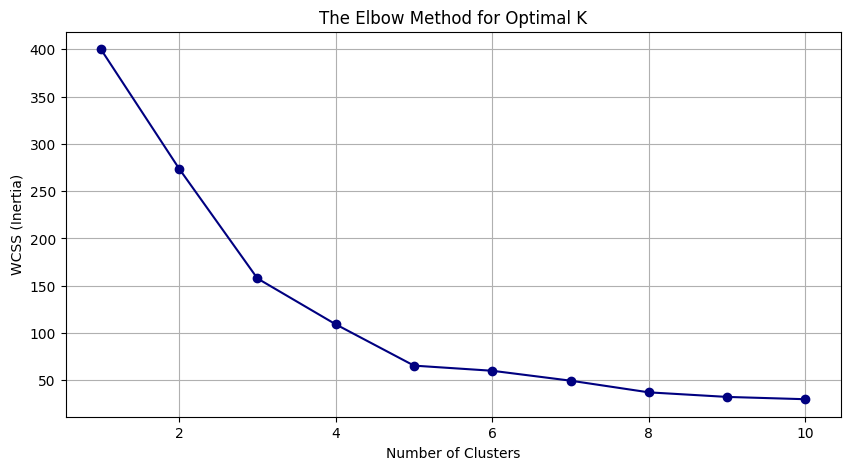

In [ ]:
wcss = []
for i in range(1, 11):
    # k-means++ ensures smart initialization of centroids
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Visualizing the Elbow
plt.figure(figsize=(10,5))
plt.plot(range(1, 11), wcss, marker='o', color='navy')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

In [ ]:
# Applying K-Means with K=5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add the cluster labels to the original dataframe for analysis
df['Cluster_Label'] = y_kmeans
print("Clustering complete. Labels added to dataframe.")
df.head()

Clustering complete. Labels added to dataframe.


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_Label
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


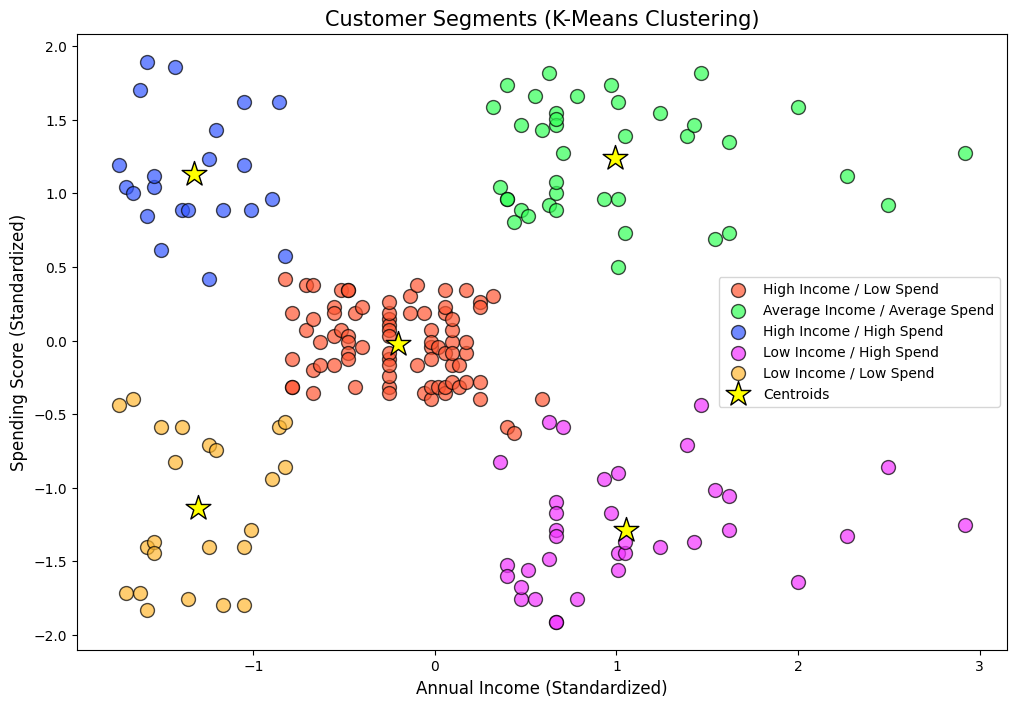

In [ ]:
plt.figure(figsize=(12, 8))

# Plotting the 5 clusters
colors = ['#FF5733', '#33FF57', '#3357FF', '#F333FF', '#FFB833']
labels = ['High Income / Low Spend', 'Average Income / Average Spend',
          'High Income / High Spend', 'Low Income / High Spend',
          'Low Income / Low Spend']

for i in range(5):
    plt.scatter(X_scaled[y_kmeans == i, 0], X_scaled[y_kmeans == i, 1],
                s=100, c=colors[i], label=labels[i], edgecolors='black', alpha=0.7)

# Plotting the Centroids (Yellow Stars)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=350, c='yellow', marker='*', label='Centroids', edgecolors='black')

plt.title('Customer Segments (K-Means Clustering)', fontsize=15)
plt.xlabel('Annual Income (Standardized)', fontsize=12)
plt.ylabel('Spending Score (Standardized)', fontsize=12)
plt.legend(loc='best')
plt.show()